In [71]:
# Netflix Movies Data Analysis

## Project Overview

#This project analyzes Netflix movie data to understand trends in movie production, genres, ratings, countries, release years, and movie duration.
#The analysis focuses on data cleaning, exploratory data analysis,statistical summaries, filtering, grouping, and visualization using Python and Pandas.

## Business Questions

#1. What is the most common movie genre?
#2. Which movie has the highest rating? 
#3. How many movies were released after 2015?
#4. Which countries produce the most movies?
#5. What is the longest movie?
#6. How has movie production changed over the years?
#7. What is the frequency of each genre?
#8. What is the distribution of movie ratings?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/netflix_titles.csv")

df.isnull().sum()
df.duplicated().sum()
df["type"].value_counts()

movies = df[df["type"] == "Movie"].copy()
missing_percentage = (
    movies.isnull().mean() * 100
).sort_values(ascending=False)
print("Missing Values Percentage:\n", missing_percentage)




Missing Values Percentage:
 cast            7.747513
country         7.176643
director        3.066384
duration        0.048932
rating          0.032621
title           0.000000
show_id         0.000000
type            0.000000
release_year    0.000000
date_added      0.000000
listed_in       0.000000
description     0.000000
dtype: float64


The most common genre is: International Movies


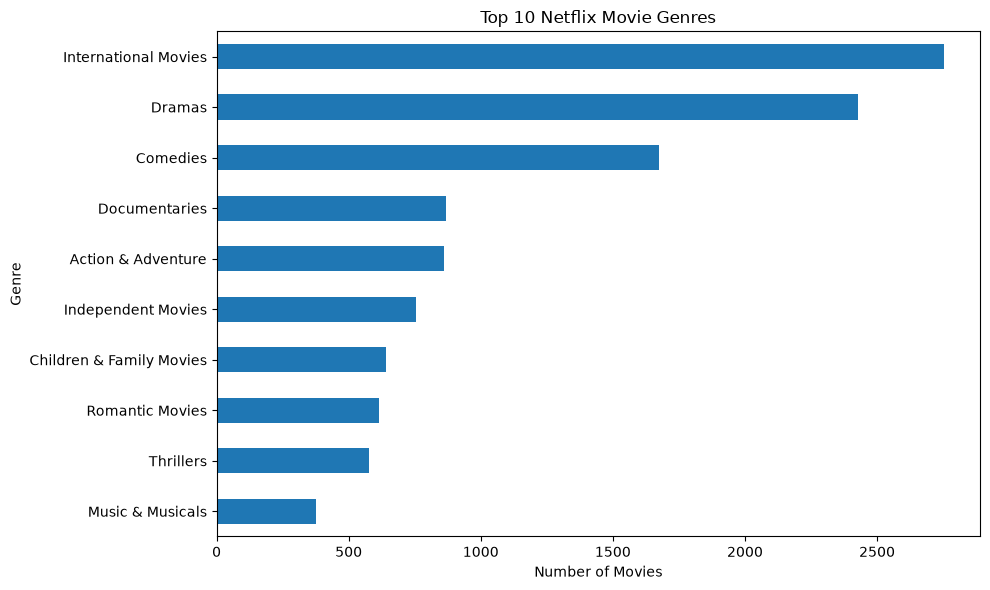

In [8]:
movies.columns = (
    movies.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

movies["date_added"] = pd.to_datetime(
    movies["date_added"],
    errors="coerce"
)

movies["duration_minutes"] = (
    movies["duration"]
    .str.extract(r"(\d+)")
    .astype(float)
)

genre_series = (
    movies["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
)
genre_frequency = genre_series.value_counts()
most_common_genre = genre_frequency.idxmax()
print(f"The most common genre is: {most_common_genre}")

plt.figure(figsize=(10, 6))
genre_frequency.head(10).sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Netflix Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()

plt.show()


In [74]:
#2 movies["rating"]-Not possible to find the highest rating as ratings are not numerical in this dataset.

In [7]:
#3 Movies After 2015

movies_after_2015=movies[movies["release_year"]>2015]
print(f"Number of movies released after 2015: {len(movies_after_2015)}")


Number of movies released after 2015: 3619


The country that produces the most movies is: United States


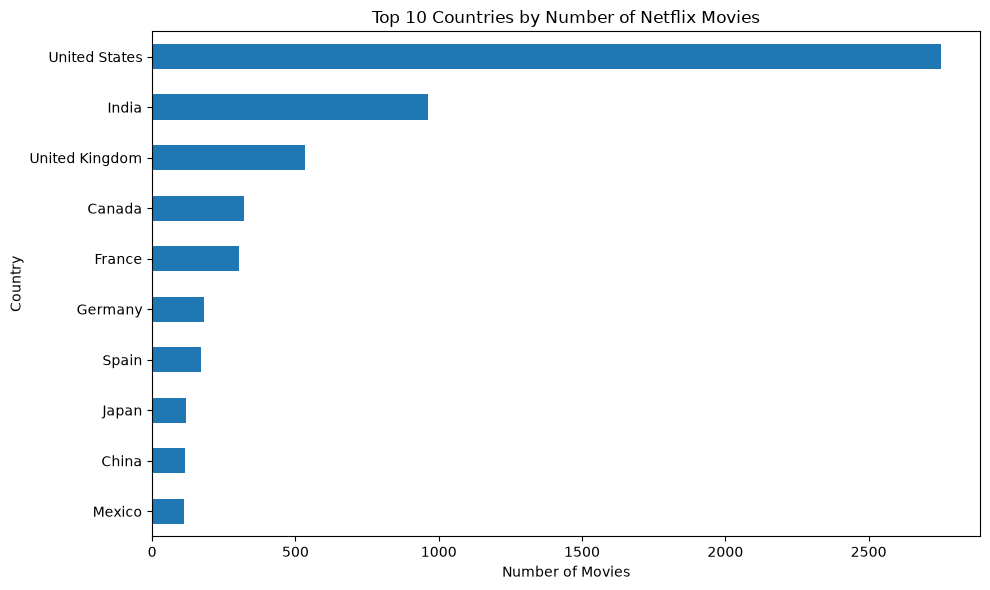

In [9]:
#4 movies by country

country_series = (
    movies["country"]
    .dropna()
    .str.split(", ")
    .explode()
)

country_frequency = country_series.value_counts()
most_common_country = country_frequency.idxmax()
print(f"The country that produces the most movies is: {most_common_country}")

plt.figure(figsize=(10, 6))
country_frequency.head(10).sort_values().plot(
    kind="barh"
)
plt.title("Top 10 Countries by Number of Netflix Movies")
plt.xlabel("Number of Movies")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [77]:
#5 longest movie

longest_movie = movies.loc[movies["duration_minutes"].idxmax()]
print(f"The longest movie is: {longest_movie['title']} with a duration of ({longest_movie['duration_minutes']} minutes)")


The longest movie is: Black Mirror: Bandersnatch with a duration of (312.0 minutes)


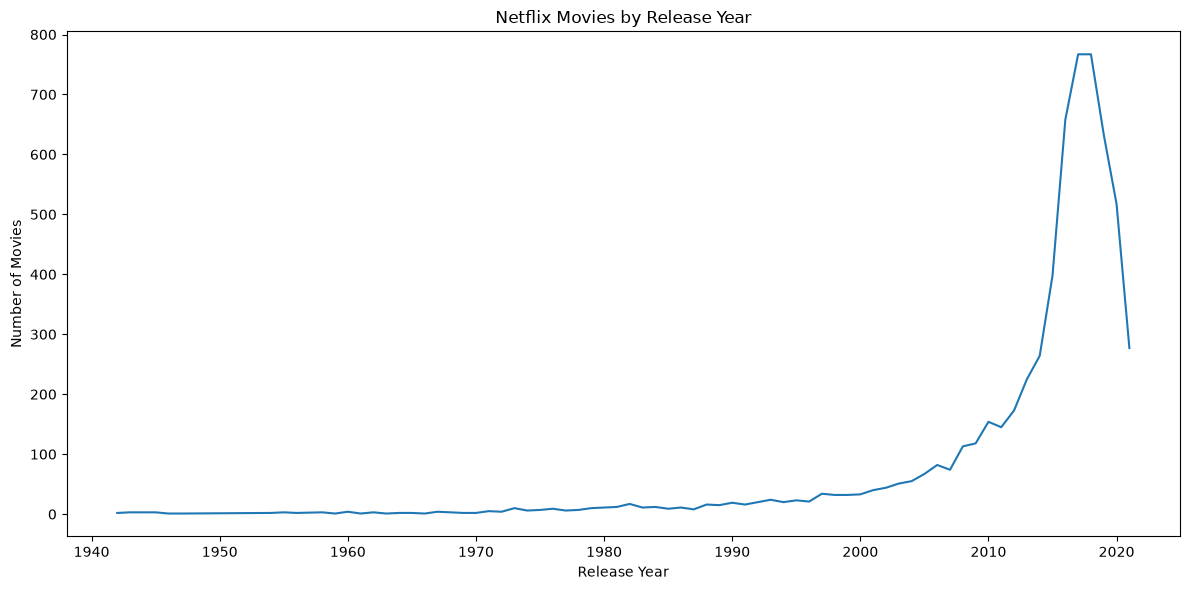

In [10]:
#6 Year-Wise Trends

movies_per_year = (
    movies["release_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))
movies_per_year.plot()
plt.title("Netflix Movies by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

<Axes: ylabel='listed_in'>

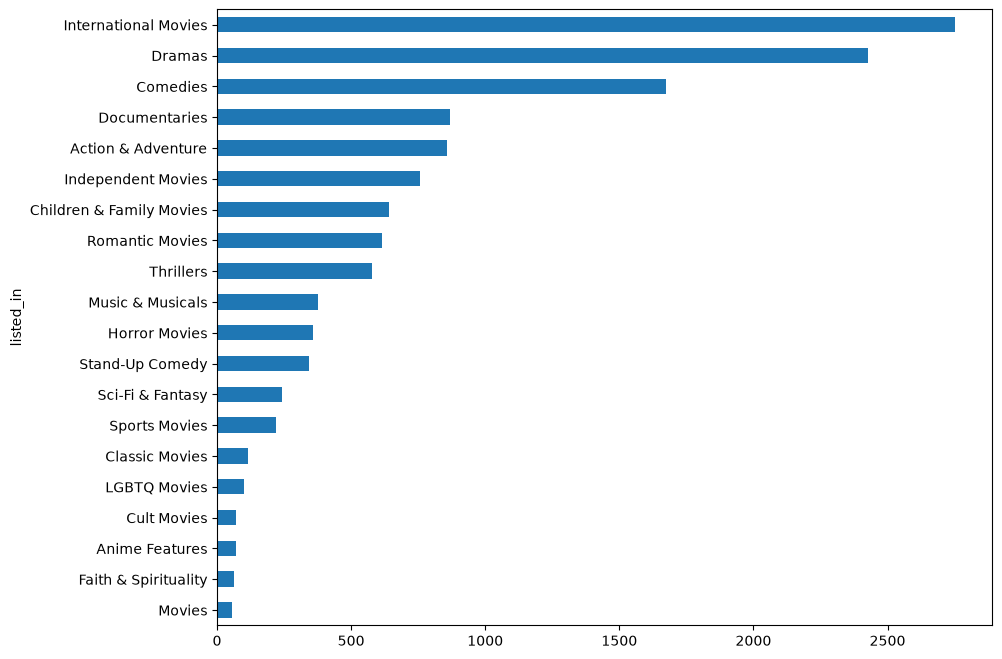

In [79]:
#7 genre frequency

genre_frequency.head(20).sort_values().plot(
    kind="barh",
    figsize=(10, 8)
)   

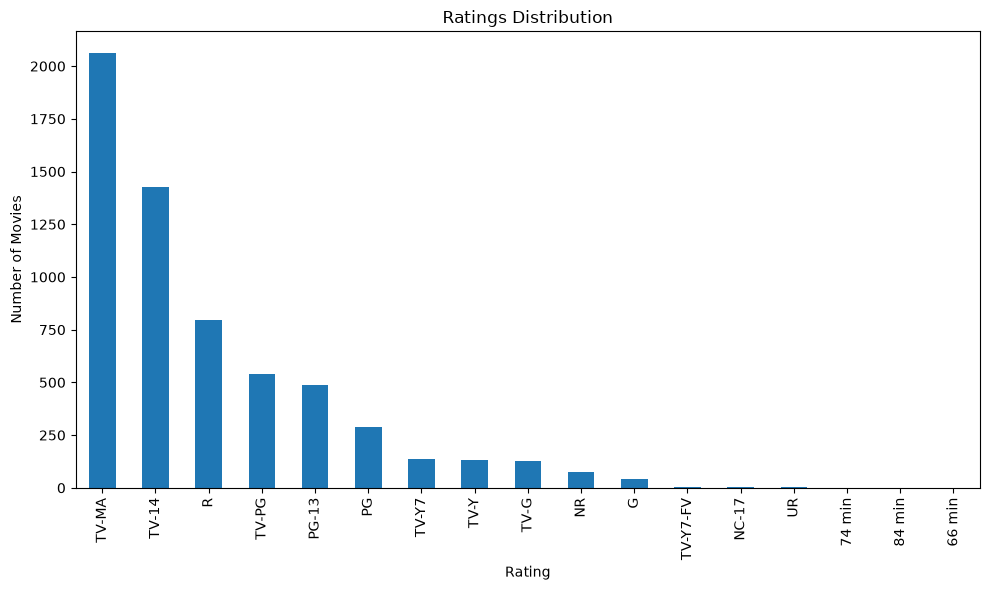

In [80]:
#8 ratings distribution

ratings_distribution = movies["rating"].value_counts()
ratings_distribution.plot(kind="bar", figsize=(10, 6))
plt.title("Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.show()

The average movie duration is: 99.57718668407311 minutes
The median movie duration is: 98.0 minutes


<Axes: xlabel='decade'>

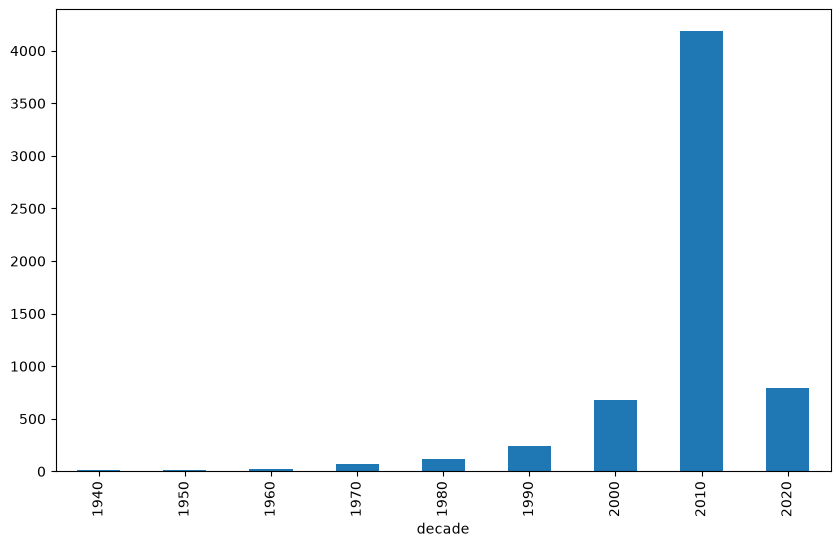

In [81]:
#average movie duration
print(f"The average movie duration is: {movies['duration_minutes'].mean()} minutes")
#median movie duration
print(f"The median movie duration is: {movies['duration_minutes'].median()} minutes")

#movies by decade
movies["decade"] = (movies["release_year"] // 10) * 10
movies.groupby("decade").size().plot(kind="bar", figsize=(10, 6))

In [ ]:
movies["release_year"].describe()



count    6131.000000
mean     2013.121514
std         9.678169
min      1942.000000
25%      2012.000000
50%      2016.000000
75%      2018.000000
max      2021.000000
Name: release_year, dtype: float64

In [ ]:
#SUMMARY
#The analysis of Netflix movie data reveals several insights. The most common genre is identified, and the country producing the most movies is highlighted. The number of movies released after 2015 is quantified, and the longest movie is specified. Year-wise trends in movie production are visualized, along with the frequency of each genre and the distribution of movie ratings. Additionally, average and median movie durations are calculated, and movies are grouped by decade to observe changes in production over time. Overall, this analysis provides a comprehensive overview of Netflix movie trends and characteristics, offering valuable insights for content creators, marketers, and viewers interested in understanding the Netflix movie landscape.

